In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all three scenario results
scenario_a = pd.read_csv("benchmark/results/scenario-a_stats.csv")
scenario_b = pd.read_csv("benchmark/results/scenario-b_stats.csv")
scenario_c = pd.read_csv("benchmark/results/scenario-c_stats.csv")

print("Scenario A columns:", scenario_a.columns.tolist())
print(scenario_a.head())

Scenario A columns: ['Type', 'Name', 'Request Count', 'Failure Count', 'Median Response Time', 'Average Response Time', 'Min Response Time', 'Max Response Time', 'Average Content Size', 'Requests/s', 'Failures/s', '50%', '66%', '75%', '80%', '90%', '95%', '98%', '99%', '99.9%', '99.99%', '100%']
   Type                  Name  Request Count  Failure Count  \
0  POST  /v1/chat/completions             21             10   
1   NaN            Aggregated             21             10   

   Median Response Time  Average Response Time  Min Response Time  \
0                 13000           18063.988638        8469.653825   
1                 13000           18063.988638        8469.653825   

   Max Response Time  Average Content Size  Requests/s  ...    66%    75%  \
0       38010.423128            337.428571    0.377801  ...  20000  26000   
1       38010.423128            337.428571    0.377801  ...  20000  26000   

     80%    90%    95%    98%    99%  99.9%  99.99%   100%  
0  28000  32

In [2]:
# Extract key metrics for each scenario
def get_metrics(df, scenario_name):
    row = df[df['Type'] == 'POST']
    return {
        'Scenario': scenario_name,
        'P50 (ms)': row['50%'].values[0],
        'P95 (ms)': row['95%'].values[0],
        'P99 (ms)': row['99%'].values[0],
        'Throughput (req/s)': row['Requests/s'].values[0],
        'Failure Count': row['Failure Count'].values[0],
    }

metrics = pd.DataFrame([
    get_metrics(scenario_a, 'A: Single Pod'),
    get_metrics(scenario_b, 'B: HPA Dynamic'),
    get_metrics(scenario_c, 'C: Pre-scaled'),
])

print(metrics.to_string(index=False))

      Scenario  P50 (ms)  P95 (ms)  P99 (ms)  Throughput (req/s)  Failure Count
 A: Single Pod     13000     35000     38000            0.377801             10
B: HPA Dynamic     26000     28000     28000            0.337173              0
 C: Pre-scaled     22000     24000     24000            0.401898              0


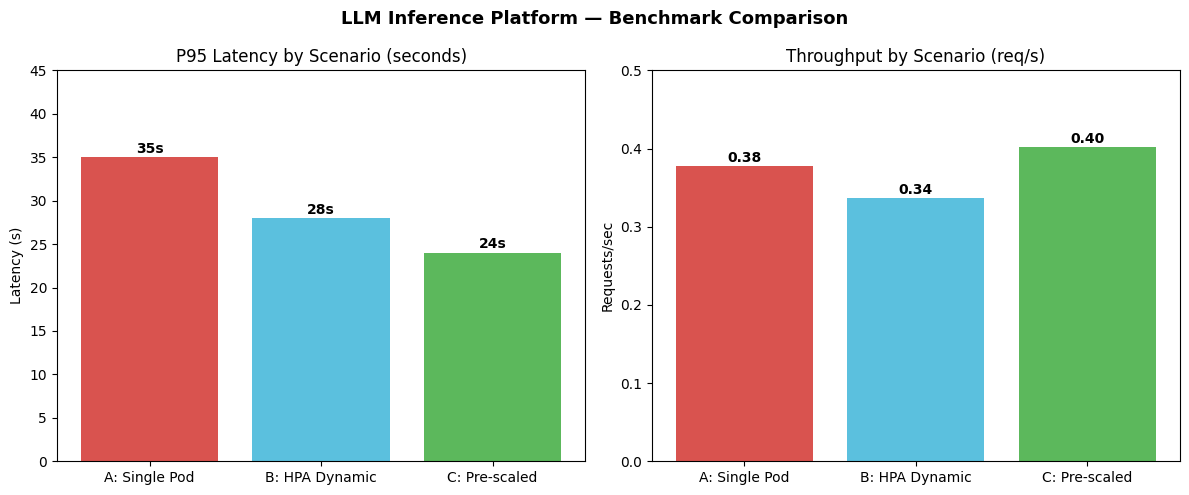

Chart saved to docs/images/benchmark-comparison.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scenarios = metrics['Scenario']

# P95 Latency comparison
axes[0].bar(scenarios, metrics['P95 (ms)'] / 1000, color=['#d9534f', '#5bc0de', '#5cb85c'])
axes[0].set_title('P95 Latency by Scenario (seconds)')
axes[0].set_ylabel('Latency (s)')
axes[0].set_ylim(0, 45)
for i, v in enumerate(metrics['P95 (ms)'] / 1000):
    axes[0].text(i, v + 0.5, f'{v:.0f}s', ha='center', fontweight='bold')

# Throughput comparison
axes[1].bar(scenarios, metrics['Throughput (req/s)'], color=['#d9534f', '#5bc0de', '#5cb85c'])
axes[1].set_title('Throughput by Scenario (req/s)')
axes[1].set_ylabel('Requests/sec')
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(metrics['Throughput (req/s)']):
    axes[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('LLM Inference Platform — Benchmark Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/images/benchmark-comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to docs/images/benchmark-comparison.png")